In [96]:
#Loop(range) your step size to go from .01 to 1, steps of .05 
#Plot each step-size run, keep an eye on how the error is related to the
#step-size, print the error(current run vs first run) for each point, and the total
#accumulated error for each run.

import numpy as np
import matplotlib.pyplot as plt

Step_size Array: [0.01 0.06 0.11 0.16 0.21 0.26 0.31 0.36 0.41 0.46 0.51 0.56 0.61 0.66
 0.71 0.76 0.81 0.86 0.91 0.96]

Individual Errors for step size:  0.01
X point:  0.0 | Error:  0.0
X point:  0.01 | Error:  0.0
X point:  0.02 | Error:  0.0
X point:  0.03 | Error:  0.0
X point:  0.04 | Error:  0.0
X point:  0.05 | Error:  0.0
X point:  0.06 | Error:  0.0
X point:  0.07 | Error:  0.0
X point:  0.08 | Error:  0.0
X point:  0.09 | Error:  0.0
X point:  0.1 | Error:  0.0
X point:  0.11 | Error:  0.0
X point:  0.12 | Error:  0.0
X point:  0.13 | Error:  0.0
X point:  0.14 | Error:  0.0
X point:  0.15 | Error:  0.0
X point:  0.16 | Error:  0.0
X point:  0.17 | Error:  0.0
X point:  0.18 | Error:  0.0
X point:  0.19 | Error:  0.0
X point:  0.2 | Error:  0.0
X point:  0.21 | Error:  0.0
X point:  0.22 | Error:  0.0
X point:  0.23 | Error:  0.0
X point:  0.24 | Error:  0.0
X point:  0.25 | Error:  0.0
X point:  0.26 | Error:  0.0
X point:  0.27 | Error:  0.0
X point:  0.28 | Error:  0.0
X 


Individual Errors for step size:  0.91
X point:  0.0 | Error:  0.0
X point:  1.0 | Error:  0.9526195558947532
X point:  2.0 | Error:  0.6548120533942785
Step Size: 0.91 | Total Error vs First Run: 1.6074

Individual Errors for step size:  0.9600000000000001
X point:  0.0 | Error:  0.0
X point:  1.0 | Error:  1.0526195558947533
X point:  2.0 | Error:  0.8288120533942787
Step Size: 0.96 | Total Error vs First Run: 1.8814


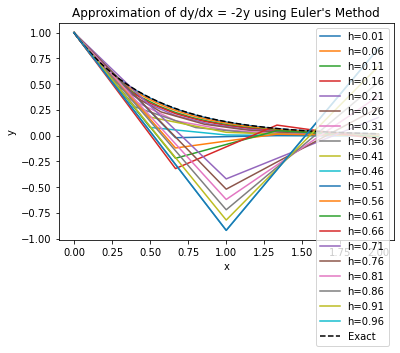

In [105]:
#creating the for loop
step_size= np.arange(0.01, 1.01, 0.05)
error_array=[]#error array
h_array= []
print ("Step_size Array:", step_size)
#Firsts
first_x = None
first_y = None

#Function for dy/dx=-2*y
def f(x,y):
    return -2*y

#Exact solution for finding the error
def exact_sol(x):
    return np.exp(-2*x)


# Define parameters
for h in step_size: # step size
    x_start, x_end = 0, 2
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps +1)
    y_values = np.zeros(num_steps + 1)
    
    # Initial condition
    y_values[0] = 1
    
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    if first_x is None:
        first_x = x_values.copy()
        first_y = y_values.copy()
    
    #Error Calculation
    y_true= exact_sol(x_values)
    y_step = np.interp(x_values, first_x, first_y)
    error_step= np.abs(y_values-y_step)
    
    #Step size
    print("\nIndividual Errors for step size: ", h)
    for j in range (len(x_values)):
        print("X point: ", x_values[j], "| Error: ", error_step[j])
    error_step_vs_first=np.sum(error_step)
    total_error = np.sum(error_step_vs_first)
    
    # Print current status
    print(f"Step Size: {h:.2f} | Total Error vs First Run: {total_error:.4f}")

    plt.plot(x_values, y_values, label=f"h={h:.2f}")
    
    
# Plot the results
x_fine = np.linspace(0, 2, 100)
plt.plot(x_fine, exact_sol(x_fine), 'k--', label='Exact')
plt.plot(x_values, y_values)   
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()